# MPG Bivariate Analysis — Example
Demonstrates `plot_data_by_varname` with sample data from the MPG dataset.

In [ ]:
from  src.bivariate_functions import categorize_into_deciles_with_stats, plot_data_by_varname, plot_data_by_varname_plotly
import pandas as pd
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
# Load the mtcars dataset
df = sns.load_dataset('mpg').dropna()  # Using mpg as a car-related dataset
display(df)
# Define the target column and columns to drop
target_column = "mpg"  # Miles per gallon as the target column
drop_cols = ["name"]

# Validate input columns
if target_column not in df.columns:
    raise ValueError(f"Target column '{target_column}' is not in the DataFrame.")
for col in drop_cols:
    if col not in df.columns:
        raise ValueError(f"Column '{col}' in drop_cols is not in the DataFrame.")
df["origin"]=df["origin"].astype(str)

# Initialize an empty DataFrame to store results
bivariate_statistics = pd.DataFrame()
visualizations = {}

# Identify columns to evaluate
cols_to_evaluate = list(set(df.columns) - set([target_column]) - set(drop_cols))

# Analyze each column
for column in cols_to_evaluate:
    print(f"column: {column}")
    result = categorize_into_deciles_with_stats(
        df, column, target_column, n_deciles=10, f_decile_tree=True
    )
    bivariate_statistics = pd.concat([bivariate_statistics, result], ignore_index=True)

display(bivariate_statistics)

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino
...,...,...,...,...,...,...,...,...,...
393,27.0,4,140.0,86.0,2790,15.6,82,usa,ford mustang gl
394,44.0,4,97.0,52.0,2130,24.6,82,europe,vw pickup
395,32.0,4,135.0,84.0,2295,11.6,82,usa,dodge rampage
396,28.0,4,120.0,79.0,2625,18.6,82,usa,ford ranger


column: origin
column: acceleration
95
column: weight
346
column: model_year
13
column: horsepower
93
column: cylinders
5
column: displacement
81


,X_decile,varname,X_min,X_max,X_median,X_25%,X_75%,mpg_mean,mpg_std,mpg_median,mpg_25%,mpg_75%,n,n_percentage,gen_mpg_mean,discr,max_discr,x_string
0,usa,origin,NaN,NaN,NaN,NaN,NaN,20.033469,6.440384,18.50,15.000,24.000,245,62.500000,23.445918,0.145546,0.298761,usa
1,japan,origin,NaN,NaN,NaN,NaN,NaN,30.450633,6.090048,31.60,25.700,34.050,79,20.153061,23.445918,0.298761,0.298761,japan
2,europe,origin,NaN,NaN,NaN,NaN,NaN,27.602941,6.580182,26.00,23.750,30.125,68,17.346939,23.445918,0.177303,0.298761,europe
3,0,acceleration,8.0,12.1,11.35,10.625,11.90,15.609524,4.735018,14.00,13.000,16.000,42,10.714286,23.445918,0.334233,0.334233,[8.00-12.10]
4,1,acceleration,12.2,13.7,13.00,12.800,13.50,18.735714,6.049506,17.50,14.000,21.500,56,14.285714,23.445918,0.200897,0.334233,[12.20-13.70]
5,2,acceleration,13.8,15.3,14.50,14.200,14.90,25.014444,7.988750,25.00,18.125,30.800,90,22.959184,23.445918,0.066900,0.334233,[13.80-15.30]
6,3,acceleration,15.4,16.0,15.70,15.500,16.00,23.050000,5.387503,22.00,19.000,26.750,54,13.775510,23.445918,0.016886,0.334233,[15.40-16.00]
7,4,acceleration,16.1,16.9,16.50,16.400,16.60,26.823077,6.829559,26.60,20.700,31.700,39,9.948980,23.445918,0.144040,0.334233,[16.10-16.90]
8,5,acceleration,17.0,18.5,17.60,17.175,18.00,25.657143,7.199845,25.00,20.200,31.525,56,14.285714,23.445918,0.094312,0.334233,[17.00-18.50]
9,6,acceleration,18.6,24.8,19.50,19.000,21.00,27.401818,7.951601,27.00,20.500,31.400,55,14.030612,23.445918,0.168724,0.334233,[18.60-24.80]


## Plot all variables

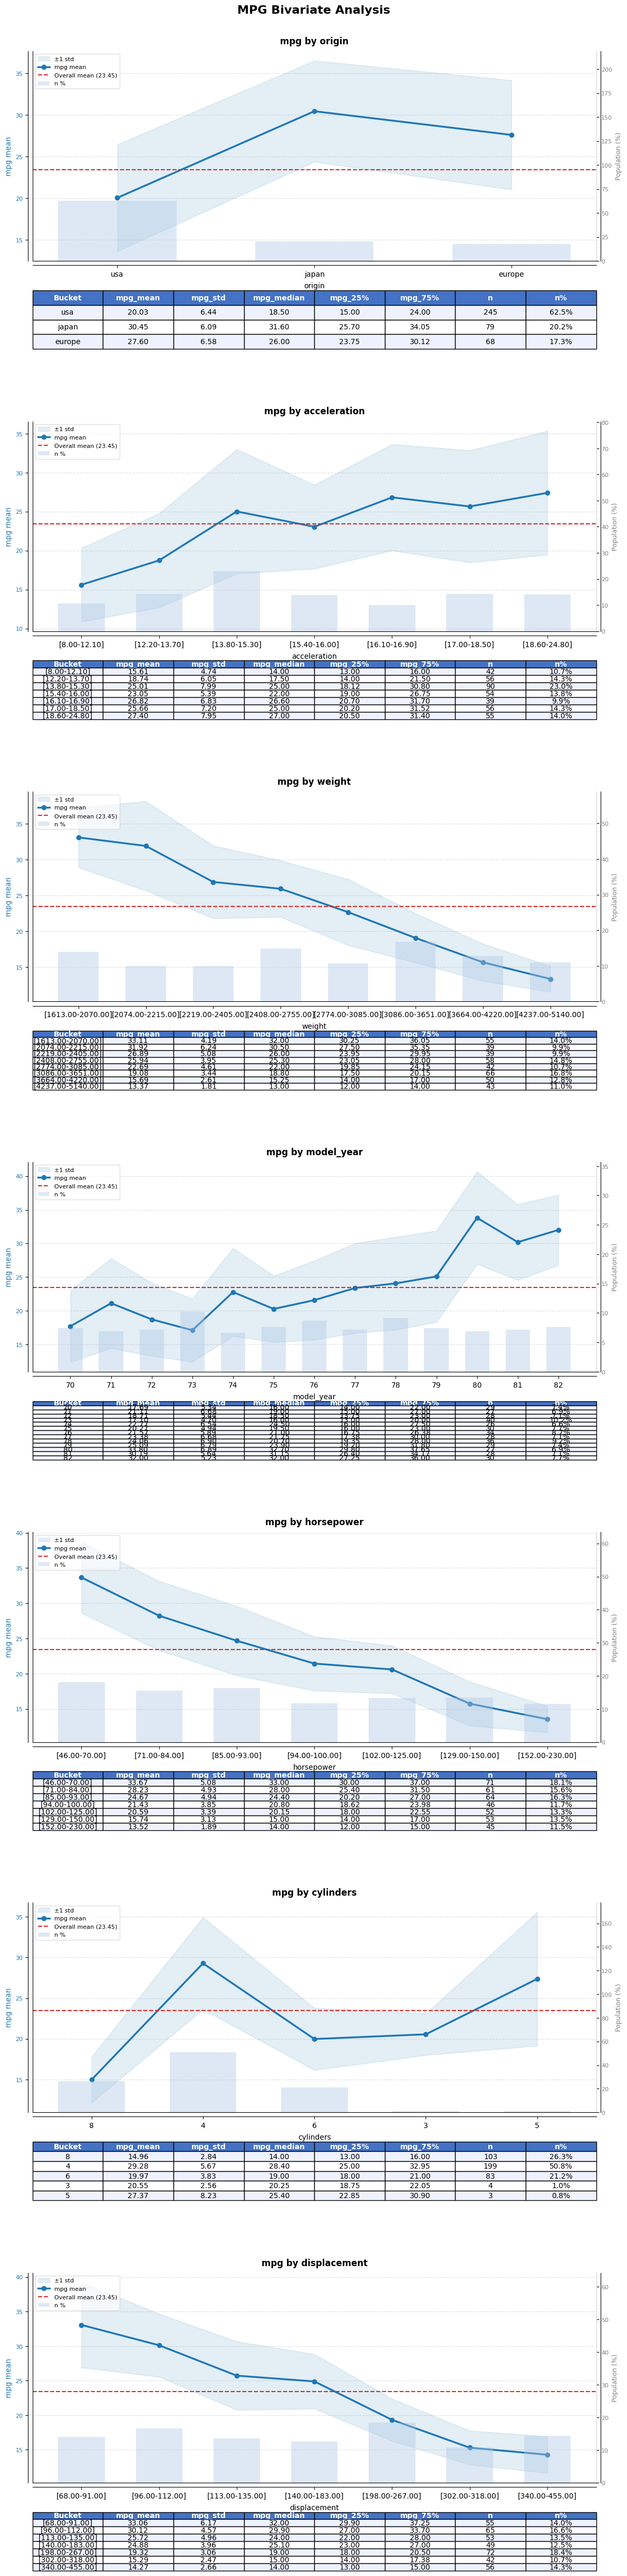

In [9]:
df = bivariate_statistics.copy()
Y = 'mpg'
vars_to_plot = df['varname'].unique().tolist()

n_vars = len(vars_to_plot)
fig, axes = plt.subplots(nrows=n_vars, ncols=1, figsize=(12, 7 * n_vars))
if n_vars == 1:
    axes = [axes]

for ax, var in zip(axes, vars_to_plot):
    plot_data_by_varname(ax, df, var, Y)

fig.suptitle('MPG Bivariate Analysis', fontsize=16, fontweight='bold', y=1.002)
plt.tight_layout(h_pad=6)
plt.savefig('bivariate_mpg.png', dpi=150, bbox_inches='tight')
plt.show()

## Plot a single variable

In [ ]:
fig, ax = plt.subplots(figsize=(12, 7))
plot_data_by_varname(ax, df, 'weight', Y)
plt.tight_layout()
plt.show()